In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 784)
(10000, 784)


In [ ]:
def create_model():

    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(10, activation='softmax')
    ])

    return model

In [ ]:
optimizers = {
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "Adagrad": Adagrad(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.01)
}

In [ ]:
histories = {}

epochs = 20
batch_size = 32

for name, optimizer in optimizers.items():

    print(f"\nTraining using {name}")

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    histories[name] = history


Training using SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9032 - loss: 0.3387 - val_accuracy: 0.9452 - val_loss: 0.1949
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9525 - loss: 0.1659 - val_accuracy: 0.9615 - val_loss: 0.1382
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9655 - loss: 0.1195 - val_accuracy: 0.9682 - val_loss: 0.1151
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9731 - loss: 0.0928 - val_accuracy: 0.9688 - val_loss: 0.1041
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0764 - val_accuracy: 0.9716 - val_loss: 0.0982
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.0631 - val_accuracy: 0.9731 - val_loss: 0.0897
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9843 - loss: 0.0540 - val_accuracy: 0.9717 - val_loss: 0.0958
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9867 - loss: 0.0473 - 

In [ ]:
print("\nFinal Results\n")

for name, history in histories.items():

    print(f"{name}")

    print("Training Accuracy : {:.4f}".format(
        history.history['accuracy'][-1]))

    print("Validation Accuracy : {:.4f}".format(
        history.history['val_accuracy'][-1]))

    print("Training Loss : {:.4f}".format(
        history.history['loss'][-1]))

    print("Validation Loss : {:.4f}".format(
        history.history['val_loss'][-1]))

    print("-"*40)


Final Results

SGD
Training Accuracy : 0.9989
Validation Accuracy : 0.9780
Training Loss : 0.0094
Validation Loss : 0.0795
----------------------------------------
Adagrad
Training Accuracy : 0.9762
Validation Accuracy : 0.9687
Training Loss : 0.0877
Validation Loss : 0.1116
----------------------------------------
RMSprop
Training Accuracy : 0.9925
Validation Accuracy : 0.9713
Training Loss : 0.0461
Validation Loss : 0.4576
----------------------------------------
Adam
Training Accuracy : 0.9844
Validation Accuracy : 0.9634
Training Loss : 0.0754
Validation Loss : 0.3788
----------------------------------------


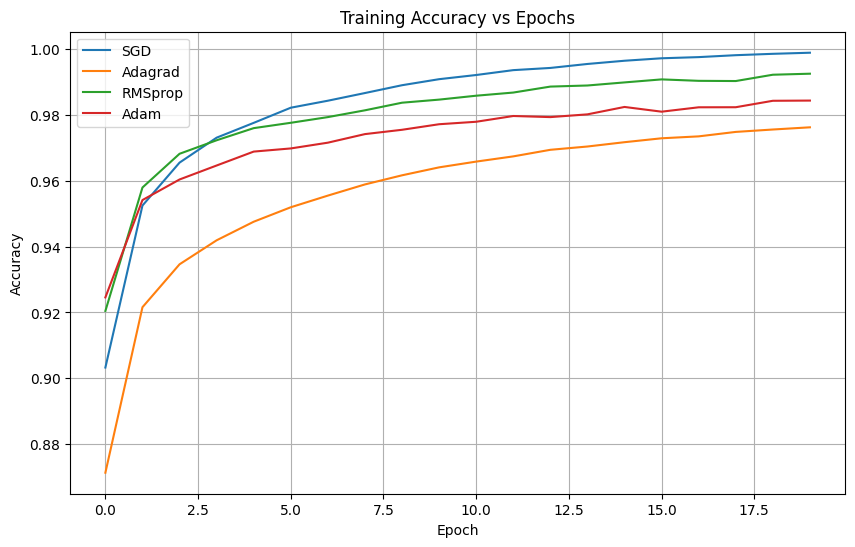

In [ ]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)

plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


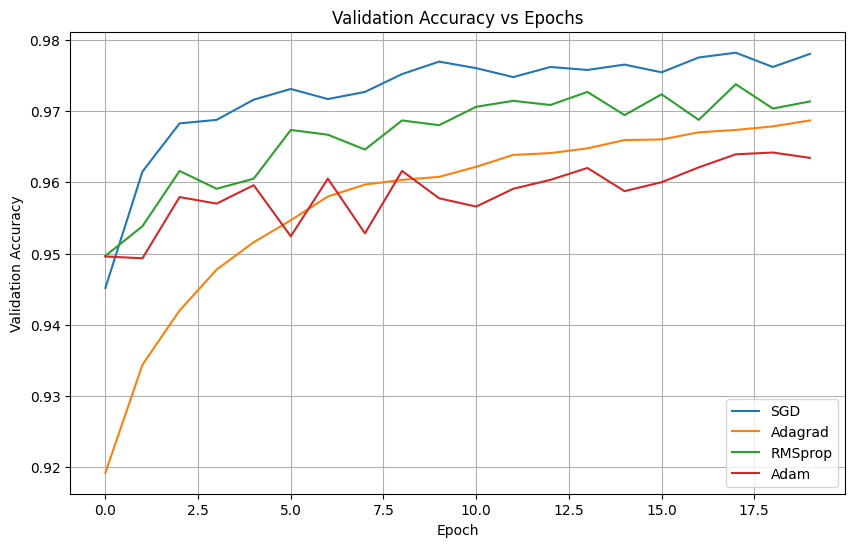

In [ ]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

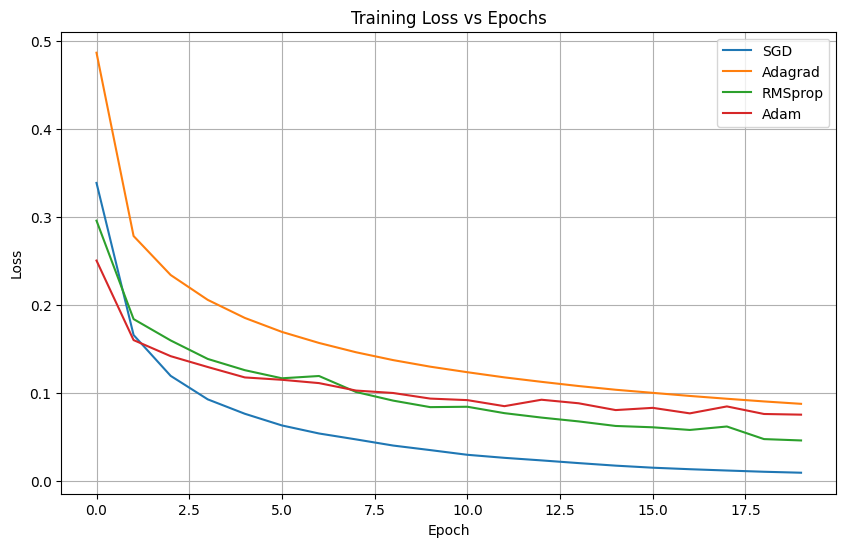

In [ ]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['loss'], label=name)

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

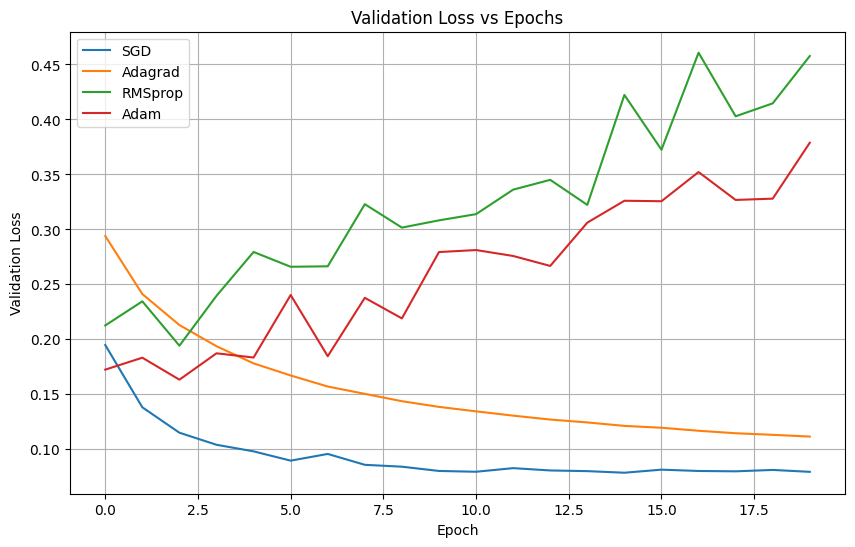

In [ ]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for name, history in histories.items():

    best_acc = max(history.history['val_accuracy'])
    epoch = history.history['val_accuracy'].index(best_acc) + 1

    print(f"{name}:")
    print(f"Best Validation Accuracy = {best_acc:.4f}")
    print(f"Reached at Epoch = {epoch}")
    print()

SGD:
Best Validation Accuracy = 0.9782
Reached at Epoch = 18

Adagrad:
Best Validation Accuracy = 0.9687
Reached at Epoch = 20

RMSprop:
Best Validation Accuracy = 0.9737
Reached at Epoch = 18

Adam:
Best Validation Accuracy = 0.9642
Reached at Epoch = 19

